# 🎨 Aesthetics Experiments — Meningioma Cohort

Side-by-side **visual style** exploration on the cleaned + imputed handoff from `output/datasets/`.

Run from **repo root** (`meningioma-atypier/`). Same cohort as the modelling notebook.

<details>
<summary><b>📦 What this notebook does</b></summary>

- Loads `mice_imputed_df.parquet` (352 rows × 43 cols)
- Compares several Python viz stacks side-by-side on the same meningioma cohort
- Each section = one library + one plot + collapsible recipe

</details>


## 00 · Setup & data load

⚙️ Core imports + cohort from cleaning handoff.

<details>
<summary>🔧 How it works</summary>

- `OUTPUT_ROOT = Path("output")` — same tree as cleaning / modelling notebooks
- Prefers **MICE-imputed** parquet; falls back to `simple_imputed_df.parquet` or `unimputed_df.parquet`
- Adds plot-friendly label: `high_grade_label` (Low grade / High grade)

</details>


In [133]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import HTML, SVG, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)

OUTPUT_ROOT = Path("output")
DATASETS_DIR = OUTPUT_ROOT / "datasets"

DATASET_CANDIDATES = [
    DATASETS_DIR / "mice_imputed_df.parquet",
    DATASETS_DIR / "simple_imputed_df.parquet",
    DATASETS_DIR / "unimputed_df.parquet",
]
for _path in DATASET_CANDIDATES:
    if _path.exists():
        DATA_PATH = _path
        break
else:
    raise FileNotFoundError(f"No parquet found under {DATASETS_DIR}")

df = pd.read_parquet(DATA_PATH)

# Plot-friendly derived columns
df = df.assign(
    high_grade_label=np.where(df["high_grade"], "High grade", "Low grade"),
)
GRADE_ORDER = ["Low grade", "High grade"]
PALETTE = {"Low grade": "#72B7B2", "High grade": "#E45756"}

print(f"✅ Loaded {DATA_PATH.name}: {len(df)} rows × {len(df.columns)} cols")
df[["age", "who_grade", "high_grade", "high_grade_label", "tumor_volume", "adc_value"]].head(3)


✅ Loaded mice_imputed_df.parquet: 352 rows × 44 cols


,age,who_grade,high_grade,high_grade_label,tumor_volume,adc_value
0,67.0,1,False,Low grade,36.5,0.88
1,76.0,1,False,Low grade,6.86,0.94
2,73.0,2,True,High grade,40.9,0.6


### 🧰 Visualization libraries

Gallery of stacks used in this notebook — all installed in your environment.

<details>
<summary><b>Library roster</b></summary>

| Library | Role |
|---------|------|
| **matplotlib** | Low-level canvas — full pixel control, journal export |
| **seaborn** | Statistical plots on matplotlib — distributions, heatmaps |
| **plotly** | Interactive HTML — hover, zoom, e-poster screens |
| **altair** | Declarative Vega-Lite — layered grammar, clean composition |
| **plotnine** | ggplot2 grammar in Python — faceting, density, boxplots |
| **bokeh** | Web-native interactivity — tooltips, pan/zoom |
| **pygal** | Glossy SVG output — lightweight vector graphics |
| **hvplot** | HoloViz one-liners — quick exploratory hexbins etc. |
| **lets-plot** | Kotlin ggplot engine — crisp box/violin aesthetics |
| **scienceplots** | Publication matplotlib styles — IEEE/Nature-like typography |

</details>


In [134]:
def section_divider(emoji: str, title: str, body_html: str) -> None:
    """Render a horizontal rule + collapsible recipe block."""
    display(
        HTML(
            f"""
            <hr style="border:none;border-top:3px solid #ddd;margin:2rem 0 1rem;">
            <h3>{emoji} {title}</h3>
            <details>
              <summary><b>Recipe</b> — libs · snippet</summary>
              {body_html}
            </details>
            """
        )
    )


---

## 01 · Matplotlib — layered histogram

📊 Age distribution split by high-grade flag.

<details>
<summary>Recipe — <code>matplotlib</code></summary>

- **Libs:** `matplotlib.pyplot`, `numpy`
- **Pattern:** `sns.histplot(..., kde=True, stat="count")` + `ax.legend()`
- **Style tip:** `plt.style.use("seaborn-v0_8-whitegrid")` for soft grid

```python
fig, ax = plt.subplots()
for label in GRADE_ORDER:
    ages = df.loc[df["high_grade_label"] == label, "age"].dropna()
    sns.histplot(ages, bins=18, kde=True, stat="count", alpha=0.55, color=PALETTE[label], label=label, ax=ax)
ax.set(xlabel="Age (years)", ylabel="Patients", title="...")
ax.legend()
plt.show()
```

</details>


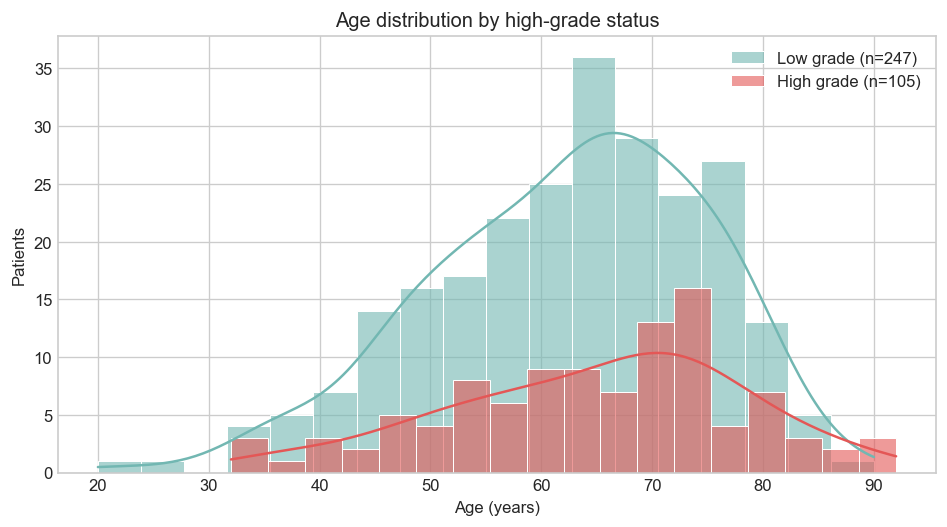

In [135]:
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
    for label in GRADE_ORDER:
        sub = df.loc[df["high_grade_label"] == label]
        ages = sub["age"].dropna()
        sns.histplot(
            ages,
            bins=18,
            kde=True,
            stat="count",
            alpha=0.6,
            label=f"{label} (n={len(sub)})",
            color=PALETTE[label],
            edgecolor="white",
            linewidth=0.6,
            ax=ax,
        )
    ax.set(xlabel="Age (years)", ylabel="Patients", title="Age distribution by high-grade status")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


---

## 02 · Seaborn — violin + strip

🎻 Tumor volume by high-grade status with individual points.

<details>
<summary>Recipe — <code>seaborn</code></summary>

- **Libs:** `seaborn`, `matplotlib.pyplot`
- **Pattern:** `sns.violinplot(..., inner="quartile")` + `sns.stripplot(..., alpha=, jitter=)`
- **Palette:** pass dict mapping category → hex

```python
sns.violinplot(data=df, x="high_grade_label", y="tumor_volume", hue="high_grade_label", palette=PALETTE)
sns.stripplot(data=df, x="high_grade_label", y="tumor_volume", color="0.25", alpha=0.35, jitter=0.25)
```

</details>


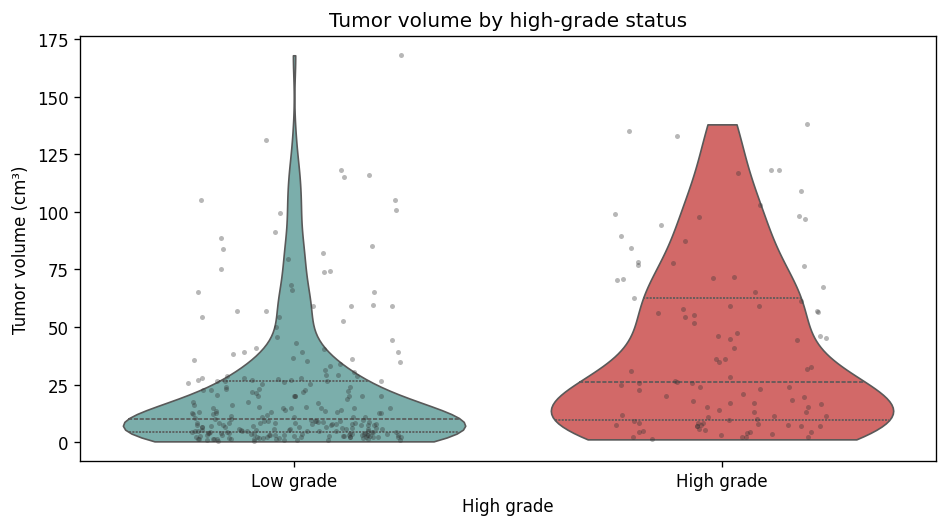

In [136]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
sns.violinplot(
    data=df,
    x="high_grade_label",
    y="tumor_volume",
    order=GRADE_ORDER,
    hue="high_grade_label",
    palette=PALETTE,
    inner="quartile",
    cut=0,
    linewidth=1,
    ax=ax,
    legend=False,
)
sns.stripplot(
    data=df,
    x="high_grade_label",
    y="tumor_volume",
    order=GRADE_ORDER,
    color="0.2",
    alpha=0.35,
    jitter=0.25,
    size=3,
    ax=ax,
)
ax.set(xlabel="High grade", ylabel="Tumor volume (cm³)", title="Tumor volume by high-grade status")
fig.tight_layout()
plt.show()


---

## 03 · Plotly — interactive scatter

✨ Age vs ADC value coloured by high-grade status — hover for patient-level detail.

<details>
<summary>Recipe — <code>plotly.express</code></summary>

- **Libs:** `plotly.express` (`pip install plotly`)
- **Pattern:** `px.scatter(df, x=, y=, color=, hover_data=, template="plotly_white")`
- **Output:** `fig.show()` renders inline in Jupyter

```python
import plotly.express as px
fig = px.scatter(df, x="age", y="adc_value", color="high_grade_label", template="plotly_white")
fig.show()
```

</details>


In [137]:
import plotly.express as px

plot_df = df.dropna(subset=["age", "adc_value"]).copy()
fig = px.scatter(
    plot_df,
    x="age",
    y="adc_value",
    color="high_grade_label",
    color_discrete_map=PALETTE,
    category_orders={"high_grade_label": GRADE_ORDER},
    hover_data=["patient_code", "tumor_volume", "max_diameter_cm"],
    opacity=0.75,
    trendline="ols",
    template="plotly_white",
    title="Age vs ADC value by high-grade status (OLS by grade)",
    labels={"age": "Age (years)", "adc_value": "ADC value", "high_grade_label": "High grade"},
)
fig.update_traces(marker=dict(size=9, line=dict(width=0.5, color="white")), selector=dict(mode="markers"))
fig.update_traces(line=dict(width=2.5), selector=dict(mode="lines"))
fig.show()


---

## 04 · Altair — layered bar + text

📐 Declarative high-grade counts with labels on bars.

<details>
<summary>Recipe — <code>altair</code></summary>

- **Libs:** `altair` (`pip install altair`)
- **Pattern:** `alt.Chart(df).mark_bar()` + `.encode(x=, y=, color=)` + `mark_text` layer
- **Tip:** `chart.configure_axis(grid=False)` for minimal look

```python
import altair as alt
bars = alt.Chart(counts).mark_bar().encode(x="high_grade_label", y="count", color="high_grade_label")
labels = alt.Chart(counts).mark_text(dy=-8).encode(x="high_grade_label", y="count", text="count")
(bars + labels).properties(width=420, height=280)
```

</details>


In [138]:
import altair as alt

counts = (
    df["high_grade_label"]
    .value_counts()
    .reindex(GRADE_ORDER)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "high_grade_label"})
)
bars = (
    alt.Chart(counts)
    .mark_bar(cornerRadiusTopLeft=4, cornerRadiusTopRight=4)
    .encode(
        x=alt.X("high_grade_label:N", sort=GRADE_ORDER, title="High grade"),
        y=alt.Y("count:Q", title="Patients"),
        color=alt.Color("high_grade_label:N", scale=alt.Scale(domain=GRADE_ORDER, range=list(PALETTE.values())), legend=None),
    )
)
labels = (
    alt.Chart(counts)
    .mark_text(dy=-10, fontSize=12, fontWeight="bold")
    .encode(x=alt.X("high_grade_label:N", sort=GRADE_ORDER), y="count:Q", text="count:Q")
)
(
    (bars + labels)
    .properties(width=440, height=300, title="Cohort size by high-grade status")
    .configure_axis(grid=False)
    .configure_view(strokeWidth=0)
)


alt.LayerChart(...)

---

## 05 · Plotnine — ggplot2 density

🦢 ADC value density curves faceted by sex — R-users feel at home.

<details>
<summary>Recipe — <code>plotnine</code></summary>

- **Libs:** `plotnine` (`pip install plotnine`)
- **Pattern:** `ggplot(df, aes(x, color=)) + geom_density() + facet_wrap()`
- **Theme:** `theme_minimal()` + custom `scale_color_manual`

```python
from plotnine import ggplot, aes, geom_density, facet_wrap, theme_minimal
ggplot(df, aes("adc_value", color="high_grade_label")) + geom_density() + facet_wrap("sex")
```

</details>


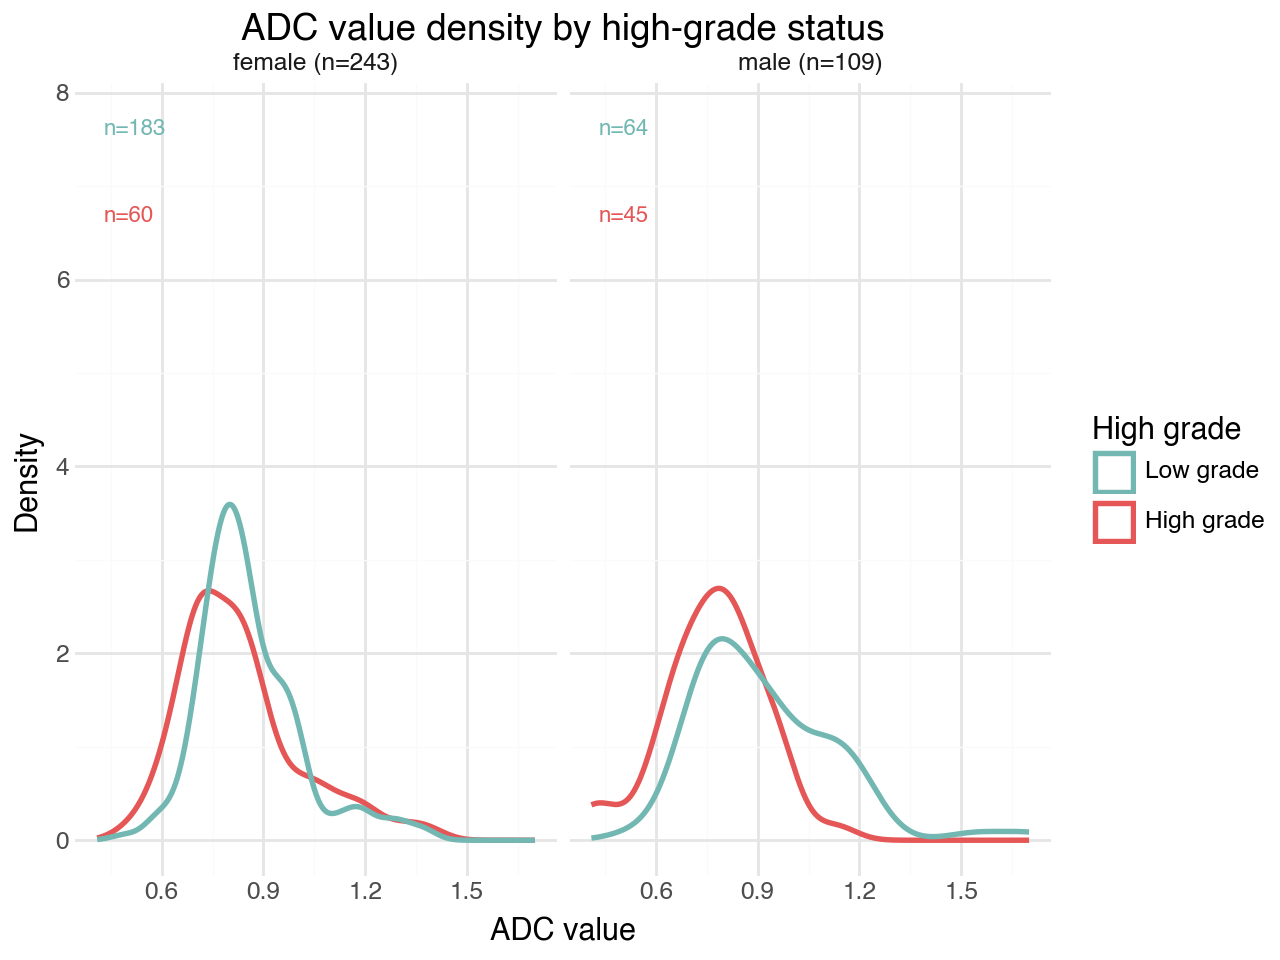

In [139]:
from plotnine import (
    aes,
    as_labeller,
    expand_limits,
    facet_wrap,
    geom_density,
    geom_text,
    ggplot,
    labs,
    scale_color_manual,
    theme_minimal,
)

plot_df = df.dropna(subset=["adc_value", "sex"])

# Facet n (sex)
n_facet = plot_df.groupby("sex", observed=True).size()
facet_labels = {str(k): f"{k} (n={v})" for k, v in n_facet.items()}

# Curve n — top-left corner (out of the density body)
_x_left = float(plot_df["adc_value"].min())
_y_rank = {g: i for i, g in enumerate(GRADE_ORDER)}
_y_top = 0.0
for _, g in plot_df.groupby(["sex", "high_grade_label"], observed=True):
    hist, _ = np.histogram(g["adc_value"].astype(float), bins=40, density=True)
    _y_top = max(_y_top, float(hist.max()))
_y_top *= 1.25  # headroom above curves

ann = (
    plot_df.groupby(["sex", "high_grade_label"], observed=True)
    .size()
    .reset_index(name="n")
    .assign(
        label=lambda d: "n=" + d["n"].astype(str),
        x=_x_left,
        y=lambda d: _y_top * (1.0 - 0.12 * d["high_grade_label"].map(_y_rank)),
    )
)

(
    ggplot(plot_df, aes(x="adc_value", color="high_grade_label"))
    + geom_density(fill="none", size=1.1, alpha=0.9)
    + geom_text(
        ann,
        aes(x="x", y="y", label="label", color="high_grade_label"),
        ha="left",
        va="top",
        size=8,
        nudge_x=0.02,
        inherit_aes=False,
        show_legend=False,
    )
    + expand_limits(y=_y_top)
    + scale_color_manual(values=[PALETTE[g] for g in GRADE_ORDER], breaks=GRADE_ORDER)
    + facet_wrap("~sex", nrow=1, labeller=as_labeller(facet_labels))
    + theme_minimal(base_size=11)
    + labs(title="ADC value density by high-grade status", x="ADC value", y="Density", color="High grade")
)


---

## 06 · Bokeh — hover scatter

🌐 Web-native scatter with tooltip — ADC (tissue) vs tumor volume (size).

<details>
<summary>Recipe — <code>bokeh</code></summary>

- **Libs:** `bokeh.plotting`, `bokeh.models` (`pip install bokeh`)
- **Pattern:** `figure(tools="hover")` + `p.circle(..., source=ColumnDataSource)`
- **Notebook:** `output_notebook()` once per session
- **Why these axes:** diameter×volume is mostly size×size; ADC×volume asks a real bivariate question

```python
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
p = figure(tools=[HoverTool(tooltips=[("High grade", "@high_grade_label")])])
p.circle("adc_value", "tumor_volume", source=src, color=factor_cmap(...))
show(p)
```

</details>


In [140]:
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap

output_notebook(hide_banner=True)

# ADC (tissue) × volume (size) — not two size proxies
src_df = df.dropna(subset=["adc_value", "tumor_volume"]).copy()
src = ColumnDataSource(src_df)
hover = HoverTool(
    tooltips=[
        ("Patient", "@patient_code"),
        ("High grade", "@high_grade_label"),
        ("ADC", "@adc_value{0.00}"),
        ("Volume (cm³)", "@tumor_volume{0.0}"),
    ]
)
p = figure(
    width=640,
    height=380,
    title="ADC value vs tumor volume (OLS by grade)",
    tools=[hover, "pan", "wheel_zoom", "reset"],
    x_axis_label="ADC value",
    y_axis_label="Tumor volume (cm³)",
)
p.scatter(
    "adc_value",
    "tumor_volume",
    source=src,
    size=9,
    alpha=0.65,
    line_color="white",
    color=factor_cmap("high_grade_label", palette=list(PALETTE.values()), factors=GRADE_ORDER),
)

# Per-grade OLS trend (exploratory; volume skew → interpret gently)
for label in GRADE_ORDER:
    sub = src_df.loc[src_df["high_grade_label"] == label, ["adc_value", "tumor_volume"]]
    if len(sub) < 3:
        continue
    x = sub["adc_value"].to_numpy(dtype=float)
    y = sub["tumor_volume"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    r = float(np.corrcoef(x, y)[0, 1])
    x_line = np.array([x.min(), x.max()])
    y_line = slope * x_line + intercept
    p.line(
        x_line,
        y_line,
        line_color=PALETTE[label],
        line_width=2.5,
        line_alpha=0.9,
        legend_label=f"{label} (r={r:.2f})",
    )

p.legend.location = "top_right"
p.legend.click_policy = "hide"
show(p)


---

## 07 · Pygal — glossy horizontal bars

💎 SVG bar chart — high-grade counts with a stylised palette.

<details>
<summary>Recipe — <code>pygal</code></summary>

- **Libs:** `pygal` (`pip install pygal`)
- **Pattern:** `Bar(style=Style(...))` → `add("series", values)` → `display(SVG(chart.render()))`
- **Note:** Pygal renders SVG strings, not matplotlib figures

```python
from pygal import HorizontalBar
from pygal.style import Style
chart = HorizontalBar(style=Style(colors=(...)), human_readable=True)
chart.add("Patients", counts)
display(SVG(chart.render(is_unicode=True)))
```

</details>


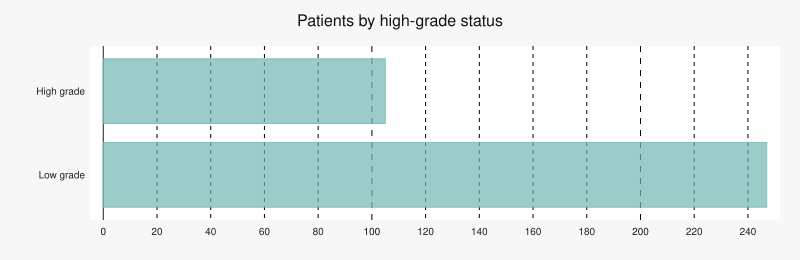

In [141]:
from pygal import HorizontalBar
from pygal.style import Style

counts = df["high_grade_label"].value_counts().reindex(GRADE_ORDER)
# Opaque light card — transparent bg + default black labels vanish on Cursor dark theme
custom_style = Style(
    colors=tuple(PALETTE[g] for g in GRADE_ORDER),
    background="#F7F7F7",
    plot_background="#FFFFFF",
    foreground="rgba(0, 0, 0, 0.87)",
    foreground_strong="#111111",
    foreground_subtle="rgba(0, 0, 0, 0.55)",
    font_family="Helvetica, Arial, sans-serif",
)
chart = HorizontalBar(
    title="Patients by high-grade status",
    style=custom_style,
    human_readable=True,
    show_legend=False,
    height=260,
)
chart.x_labels = GRADE_ORDER
chart.add("Patients", counts.tolist())
display(SVG(chart.render(is_unicode=True)))


---

## 08 · HvPlot — one-liner explorer

⚡ HoloViz quick interactive hexbin of age × tumor volume.

<details>
<summary>Recipe — <code>hvplot.pandas</code></summary>

- **Libs:** `hvplot`, `holoviews` (`pip install hvplot holoviews`)
- **Pattern:** `df.hvplot.hexbin(x=, y=, by=, cmap=, widgets=True)`
- **Backend:** defaults to Bokeh under the hood

```python
import hvplot.pandas  # noqa: F401 — registers .hvplot accessor
df.hvplot.hexbin(x="age", y="tumor_volume", by="high_grade_label", cmap="Viridis")
```

</details>


In [142]:
import holoviews as hv
import hvplot.pandas  # noqa: F401 — registers accessor

hv.extension("bokeh")

plot_df = df.dropna(subset=["age", "tumor_volume"])
plot_df.hvplot.hexbin(
    x="age",
    y="tumor_volume",
    by="high_grade_label",
    cmap="Inferno",
    gridsize=22,
    width=640,
    height=380,
    title="Age vs tumor volume (hexbin)",
    colorbar=True,
)


:HexTiles   [age,tumor_volume]

---

## 09 · Lets-Plot — Kotlin ggplot engine

🧊 Boxplot of age by high-grade status — crisp ggplot aesthetics without R.

<details>
<summary>Recipe — <code>lets_plot</code></summary>

- **Libs:** `lets_plot` (`pip install lets-plot`)
- **Pattern:** `ggplot(data) + geom_boxplot(...) + scale_fill_manual(...)`
- **Output:** renders HTML/SVG inline in Jupyter

```python
from lets_plot import ggplot, aes, geom_boxplot, geom_jitter, scale_fill_manual
ggplot(df) + geom_boxplot(aes("high_grade_label", "age", fill="high_grade_label")) + geom_jitter(width=0.12)
```

</details>


In [143]:
from lets_plot import LetsPlot, aes, geom_boxplot, geom_jitter, ggplot, ggsize, scale_fill_manual

LetsPlot.setup_html(isolated_frame=True)

plot_df = df.dropna(subset=["age"])
(
    ggplot(plot_df, aes(x="high_grade_label", y="age", fill="high_grade_label"))
    + geom_boxplot(alpha=0.75, outlier_alpha=0)
    + geom_jitter(width=0.12, alpha=0.35, size=2)
    + scale_fill_manual(values=list(PALETTE.values()))
    + ggsize(520, 320)
)


---

## 10 · SciencePlots — publication matplotlib

🖋️ Correlation heatmap of numeric MRI / tumour features — journal-ready styling.

<details>
<summary>Recipe — <code>scienceplots</code></summary>

- **Libs:** `scienceplots` (`pip install scienceplots`) + `seaborn.heatmap`
- **Pattern:** `with plt.style.context(["science", "no-latex"]): ...`
- **Style names:** `science`, `ieee`, `nature` — see package docs

```python
import scienceplots  # noqa: F401
with plt.style.context(["science", "no-latex"]):
    sns.heatmap(corr, cmap="vlag", center=0, square=True)
```

</details>


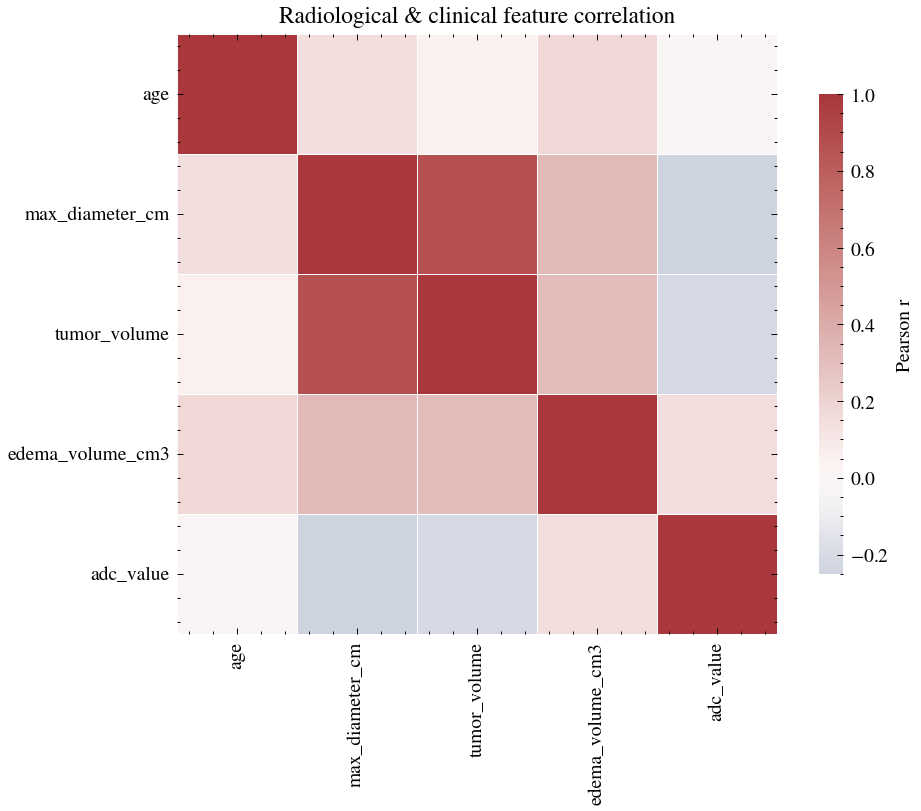

In [144]:
import scienceplots  # noqa: F401

NUMERIC_COLS = [
    "age",
    "max_diameter_cm",
    "tumor_volume",
    "edema_volume_cm3",
    "adc_value",
]
corr = df[NUMERIC_COLS].astype(float).corr()

with plt.style.context(["science", "no-latex"]):
    fig, ax = plt.subplots(figsize=(7.5, 6), dpi=140)
    sns.heatmap(
        corr,
        cmap="vlag",
        center=0,
        square=True,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"shrink": 0.8, "label": "Pearson r"},
        ax=ax,
    )
    ax.set_title("Radiological & clinical feature correlation")
    fig.tight_layout()
    plt.show()


---

## 🏁 Quick comparison

| # | Library | Plot type | Interactivity |
|---|---------|-----------|---------------|
| 01 | matplotlib | histogram | static |
| 02 | seaborn | violin + strip | static |
| 03 | plotly | scatter | ✨ hover/zoom |
| 04 | altair | bar + labels | pan/zoom in Vega |
| 05 | plotnine | density facet | static |
| 06 | bokeh | scatter + tooltip | ✨ hover/pan |
| 07 | pygal | horizontal bar SVG | static |
| 08 | hvplot | hexbin | ✨ widgets |
| 09 | lets-plot | box + jitter | static/HTML |
| 10 | scienceplots | heatmap | static |

Pick 1–2 stacks for the final report figures; keep the rest as reference recipes above.
